# AGN vs TDE Classification: Physics-Based Feature Pipeline

Classical ML pipeline in `fluctuant` (no neural network):
1. Synthetic AGN and TDE light curves
2. 16 hand-crafted, physically motivated features per light curve
3. Gradient Boosting classifier
4. Full diagnostic report: ROC, confusion matrix, feature projections, distributions, pairwise scatter, example predictions, separability analysis

ASTROMER was pretrained on MACHO *periodic* variable stars, not transients. This pipeline provides a complementary baseline built entirely from domain-expert features.

In [1]:
import matplotlib.pyplot as plt

from fluctuant.classifiers import PhysicsBasedClassifier

## Step 1. Generate synthetic light curves

In [2]:
pipeline = PhysicsBasedClassifier(seed=42)

lcs, labels = pipeline.generate_dataset(n_agn=500, n_tde=500)
print(f"Light curves: {len(lcs)}  |  AGN: {(labels == 0).sum()}  |  TDE: {(labels == 1).sum()}")

Generating 500 AGN and 500 TDE...
Light curves: 1000  |  AGN: 500  |  TDE: 500


## Step 2. Extract physics features

Sixteen scalar features per light curve, chosen to capture the key morphological differences between AGN and TDEs:

| Feature | Physical motivation |
|---|---|
| `amplitude`, `iqr`, `range_90_10` | TDEs have larger total brightness changes |
| `skewness` | TDE light curves are asymmetric (fast rise, slow decay) |
| `peak_position` | TDE peak occurs earlier in the light curve window |
| `rise_decay_ratio` | TDEs: rise time ≪ decay time |
| `rise_slope`, `decay_slope` | TDE rise is steep; decay is gradual |
| `crossings` | AGN stochastically cross the mean more often |
| `monotonic_fraction` | TDEs are more monotonically declining after peak |
| `von_neumann` | Measures autocorrelation; AGN are more correlated |
| `time_at_peak` | TDEs spend a concentrated burst near peak brightness |
| `temporal_gradient` | Rate of change across the light curve |

In [3]:
features = pipeline.extract_features()
print(f"Feature matrix: {features.shape}  ({features.shape[0]} samples × {features.shape[1]} features)")
print(f"Feature names:  {pipeline.FEATURE_NAMES}")

Extracting discriminative features...
Feature matrix: (1000, 16)
Feature matrix: (1000, 16)  (1000 samples × 16 features)
Feature names:  ['amplitude', 'mag_std', 'iqr', 'skewness', 'peak_position', 'rise_decay_ratio', 'rise_slope', 'decay_slope', 'mean_abs_change', 'crossings', 'early_late_diff', 'monotonic_fraction', 'von_neumann', 'time_at_peak', 'mag_mean', 'range_90_10']


## Step 3: Train the classifier

Features are standardized (zero mean, unit variance), then a Gradient Boosting classifier is trained on a 70/30 stratified split. 5-fold cross-validation reports the unbiased AUC on the training set.

In [4]:
clf, (X_train, X_test, y_train, y_test, y_proba) = pipeline.train()
y_pred = clf.predict(X_test)


Training...
CV ROC-AUC: 1.000 ± 0.000

              precision    recall  f1-score   support

         AGN      1.000     0.987     0.993       150
         TDE      0.987     1.000     0.993       150

    accuracy                          0.993       300
   macro avg      0.993     0.993     0.993       300
weighted avg      0.993     0.993     0.993       300

Confusion Matrix:
           Predicted
           AGN    TDE
Actual AGN  148      2
       TDE    0    150

ROC AUC: 1.000


## Step 4: Feature importance

Which of the 16 features drive the classifier? Gradient Boosting provides built-in feature importances.

In [5]:
pipeline.analyze_features()


Top 10 Features:
1. mag_mean            : 0.983
2. range_90_10         : 0.004
3. rise_decay_ratio    : 0.004
4. mag_std             : 0.003
5. amplitude           : 0.003
6. time_at_peak        : 0.002
7. peak_position       : 0.001
8. rise_slope          : 0.001
9. decay_slope         : 0.000
10. crossings           : 0.000


## Step 5: Evaluation plots

Saved to roc_curve.png


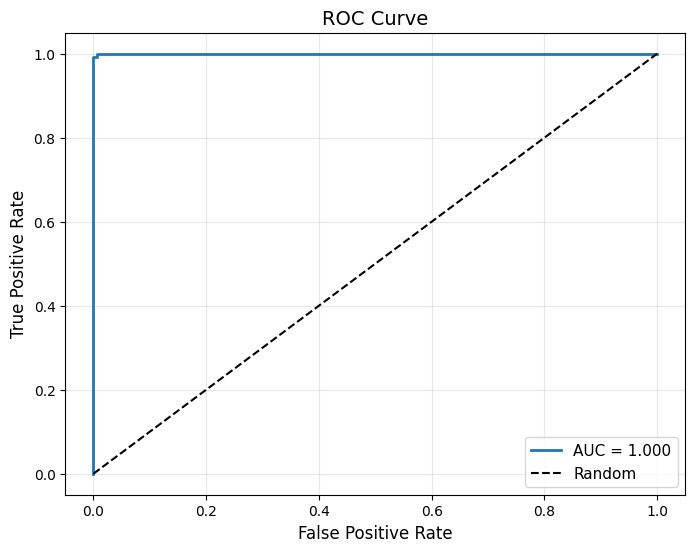

In [6]:
pipeline.plot_roc(y_test, y_proba)
plt.show()

Saved to confusion_matrix.png


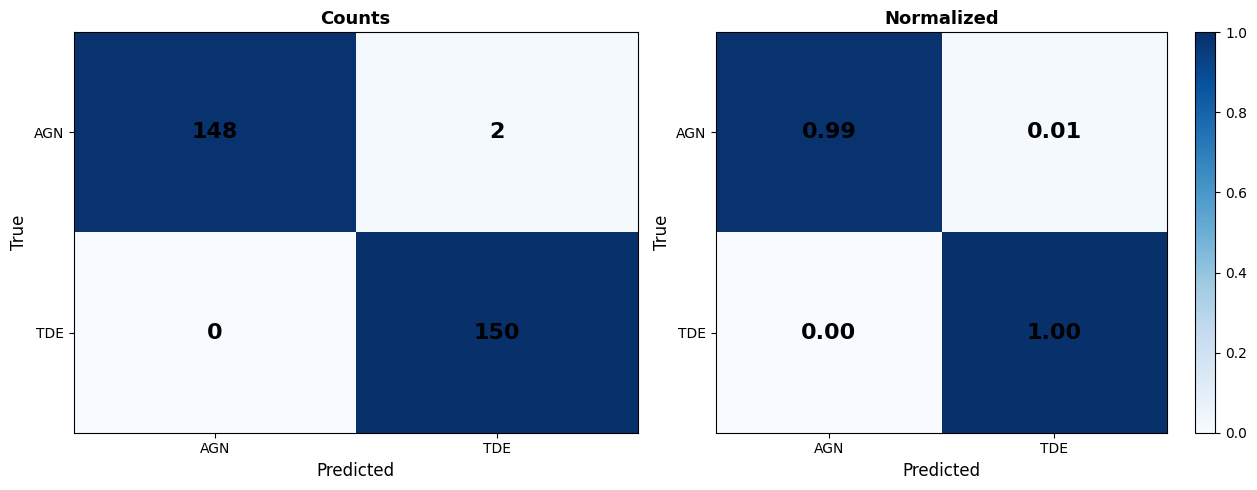

In [7]:
pipeline.plot_confusion_matrix(y_test, y_pred)
plt.show()

## Step 6: Feature space projections

PCA and t-SNE projections of the standardized 16-dim feature space. Well-separated clusters confirm the features are discriminative.


Generating feature space visualizations...
Saved to feature_space_2d.png


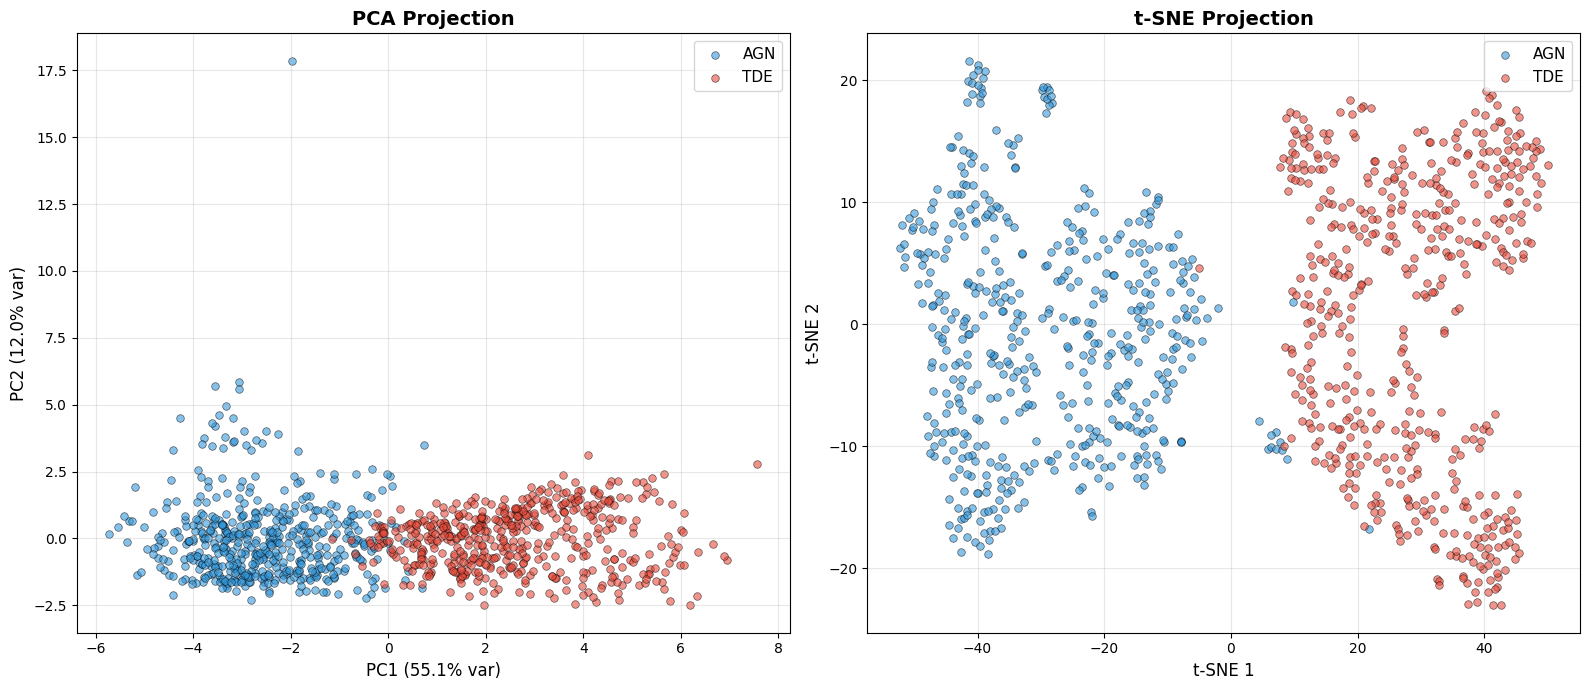

In [8]:
pipeline.plot_feature_space()
plt.show()

## Step 7: Feature distributions

Violin plots for the 8 most important features. Clear separation between AGN and TDE distributions explains the high classification performance.


Plotting feature distributions...
Saved to feature_distributions.png


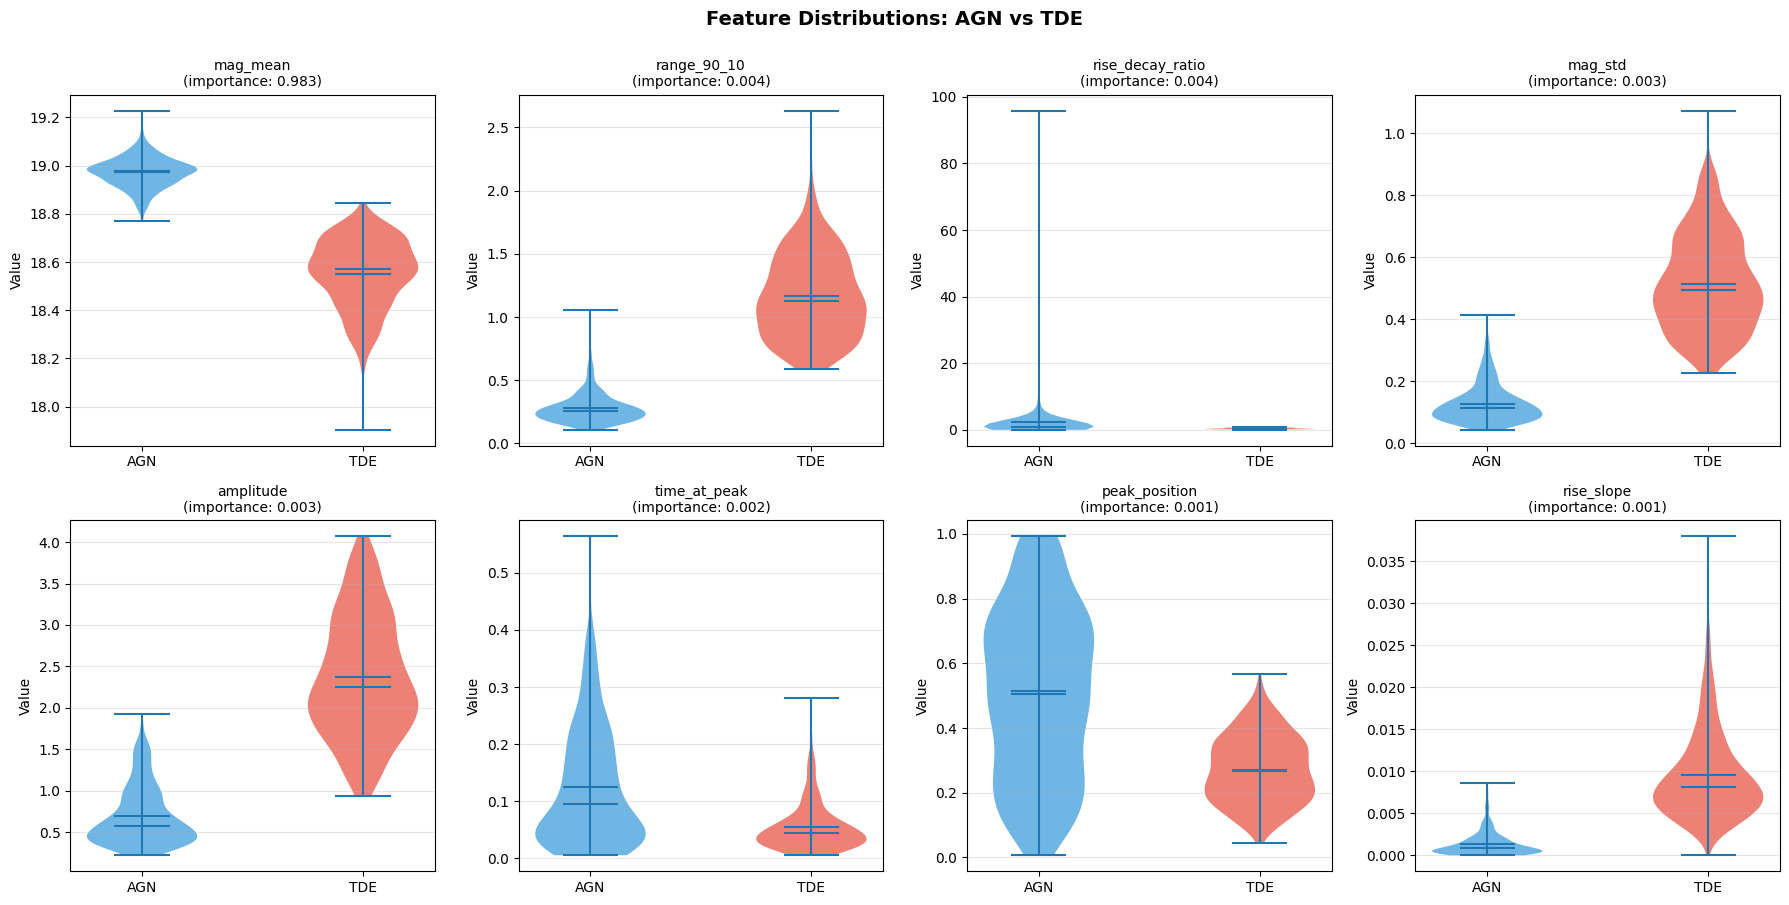

In [9]:
pipeline.plot_feature_distributions()
plt.show()

## Step 8: Pairwise feature scatter plots

Scatter plots for all pairs of the top-4 most important features.


Plotting pairwise feature relationships...
Saved to pairwise_features.png


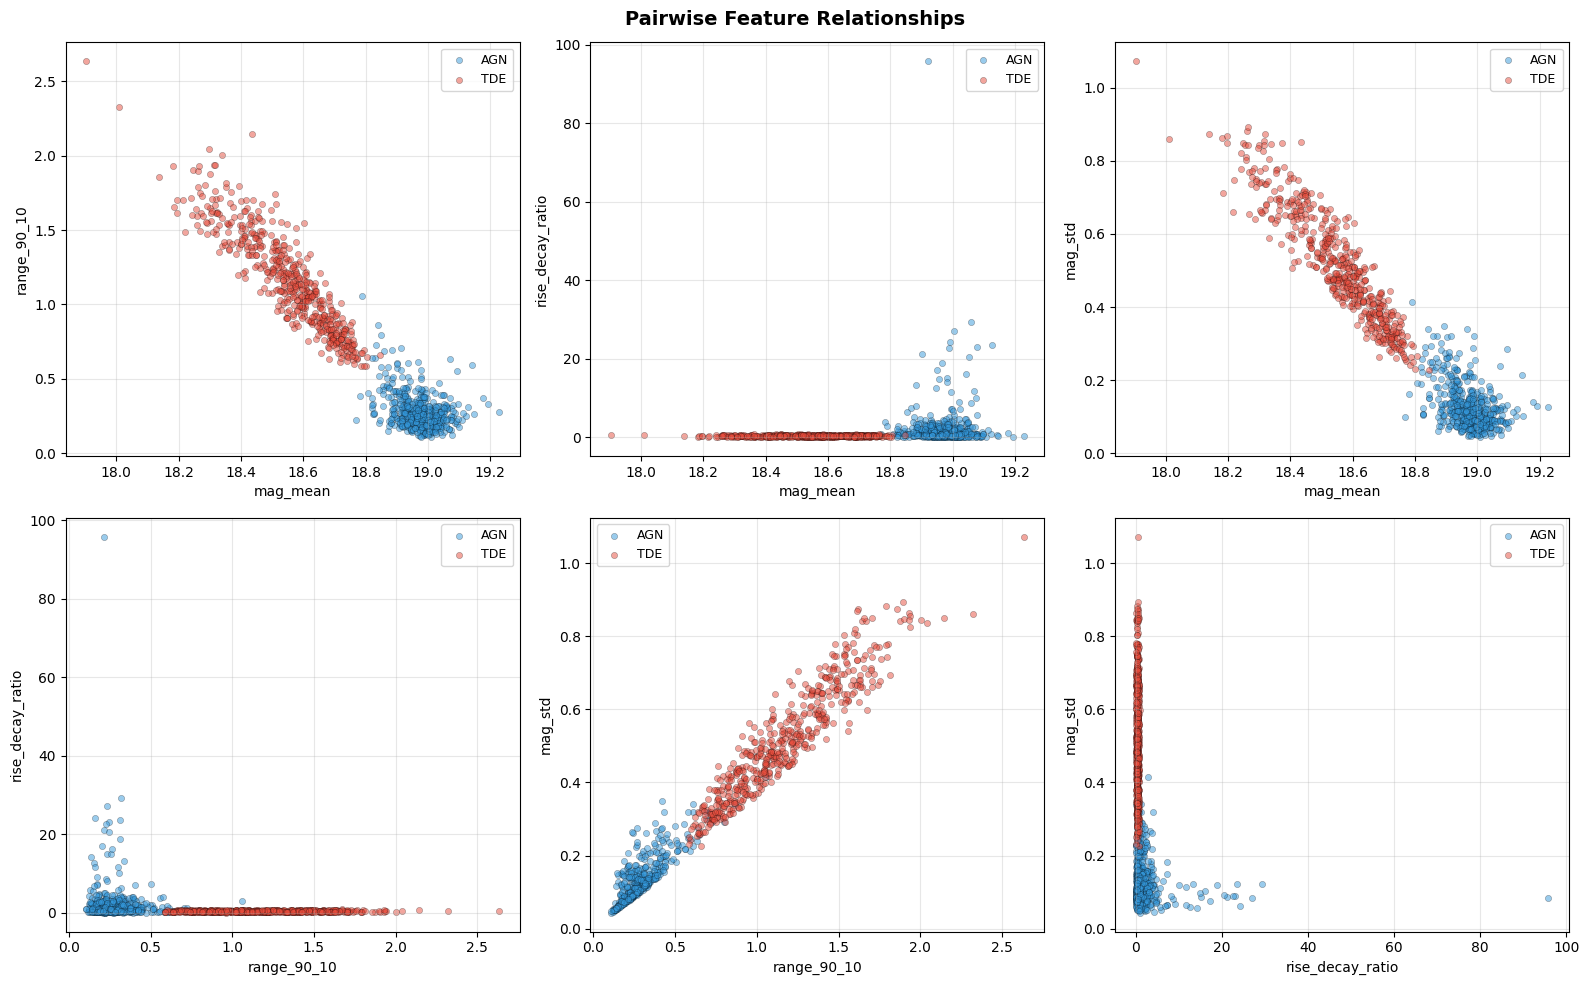

In [10]:
pipeline.plot_pairwise_features()
plt.show()

## Step 9: Example predictions

Four representative light curves with their true and predicted labels. Green titles = correct; red = misclassified.


Plotting example predictions...
Saved to example_predictions.png


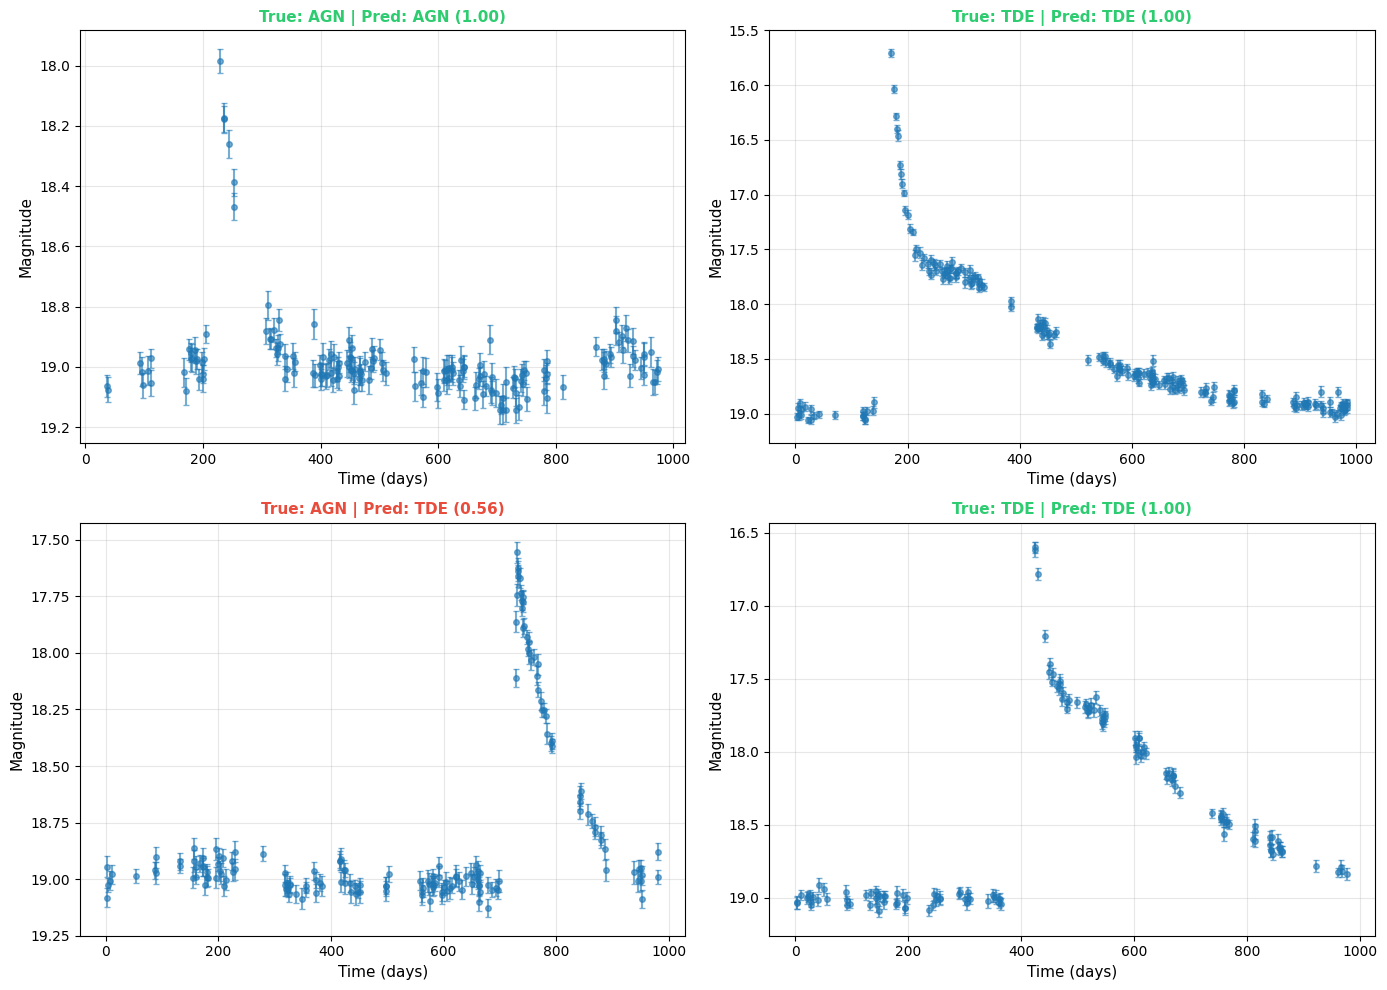

In [11]:
pipeline.plot_example_predictions(n_examples=4)
plt.show()

## Step 10: Feature separability analysis

Cohen's d effect size and Mann-Whitney U p-value for each feature, sorted by effect size. Measures individual discriminative power independently of the classifier.


Analyzing feature separability...
Saved to feature_separability.png


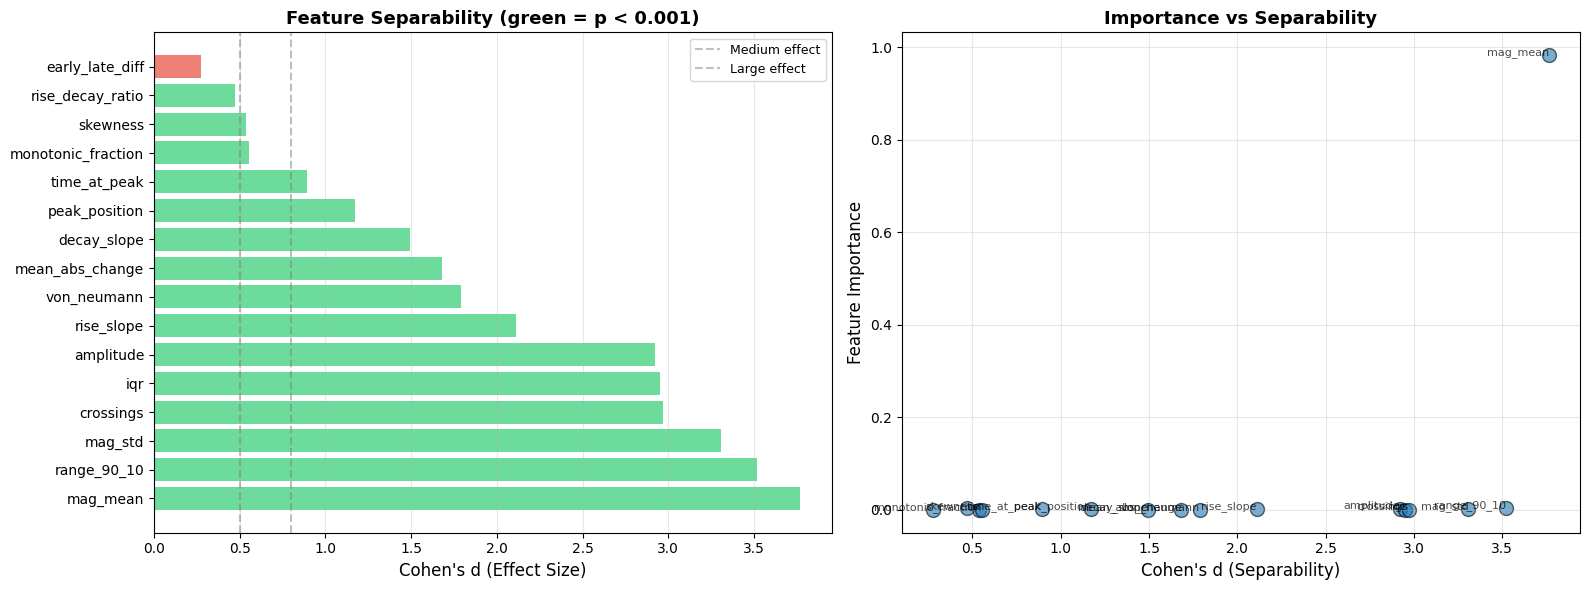

In [12]:
pipeline.plot_feature_separability()
plt.show()

## CLI equivalent

```bash
fluctuant physics \
    --n-agn 500 --n-tde 500 \
    --output-dir results/
```

This saves all seven diagnostic plots to `results/` without the interactive display.